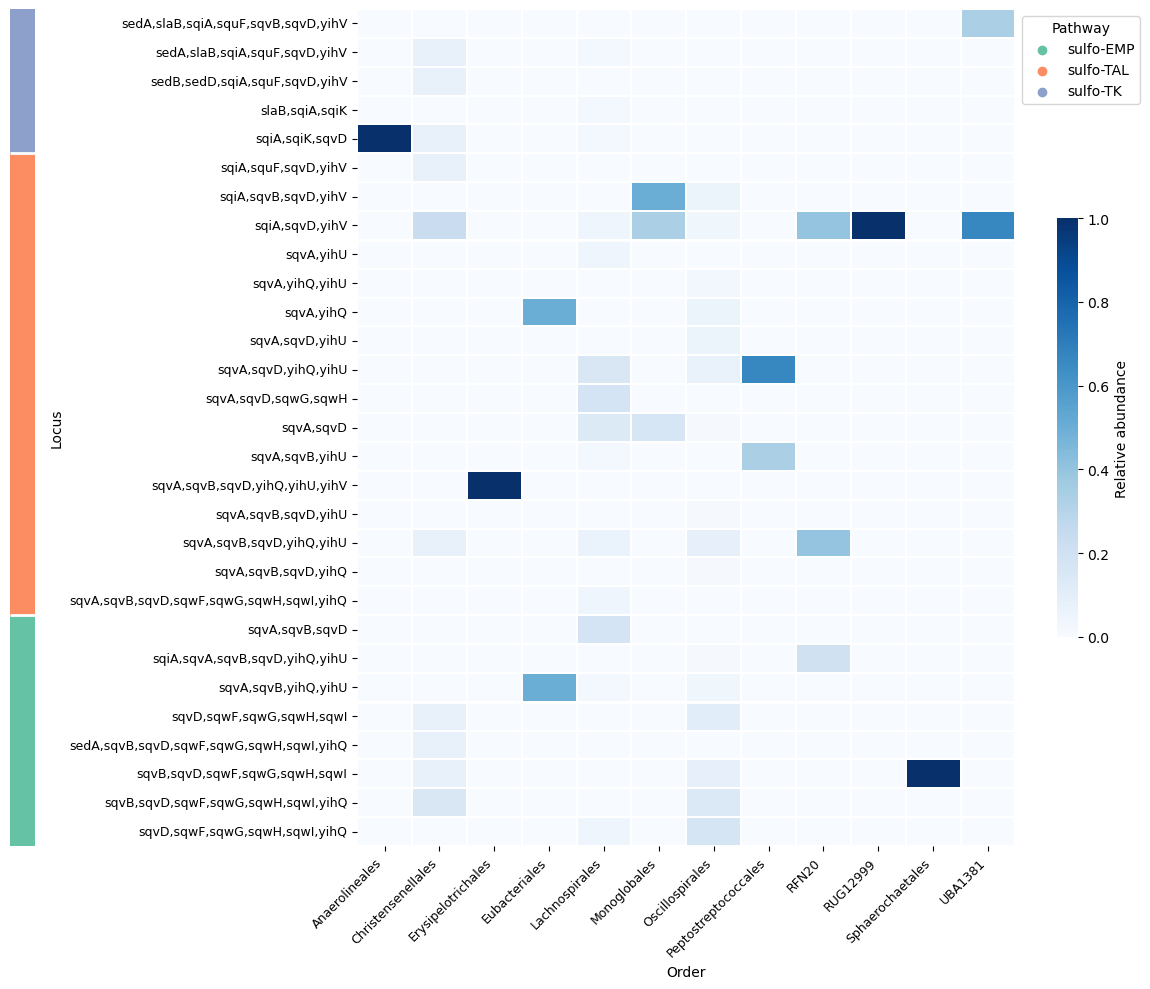

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- загрузка ---
df = pd.read_csv("../data/final_table.csv")

# --- фильтрация ---
df_filtered = df[df["SQ_score"].isin(["min_up", "min_down", "max"])].copy()

# --- извлекаем ORDER ---
df_filtered["order"] = df_filtered["taxonomy"].apply(
    lambda x: [t for t in x.split(";") if t.startswith("o__")][0].replace("o__", "")
)

# --- locus (стабильный ID генного набора) ---
df_filtered["locus"] = df_filtered["SQ_gene_content_set"].apply(
    lambda x: ",".join(sorted(x.split(",")))
)
df_filtered.to_csv("df_filtered.csv", index=False)

# --- pathway на уровне locus ---
locus_pathway = (
    df_filtered
    .groupby("locus")["SQ_pathway"]
    .agg(lambda x: x.mode()[0])
)

# --- RAW counts: locus × order ---
heatmap_df = (
    df_filtered
    .groupby(["locus", "order"])
    .size()
    .unstack(fill_value=0)
)

# --- нормализация по размерам orders ---
order_sizes = df_filtered.groupby("order").size()
heatmap_norm = heatmap_df.div(order_sizes, axis=1)

# --- добавляем pathway ---
heatmap_norm["pathway"] = heatmap_norm.index.map(locus_pathway)

# --- сортировка по pathway ---
heatmap_norm = heatmap_norm.sort_values("pathway")

# --- отделяем мета-инфо ---
pathway_labels = heatmap_norm["pathway"]
heatmap_norm = heatmap_norm.drop(columns="pathway").fillna(0)

# =========================
# VISUALIZATION
# =========================

# --- цвета pathway ---
pathway_unique = pathway_labels.unique()
palette = sns.color_palette("Set2", len(pathway_unique))
pathway_colors = dict(zip(pathway_unique, palette))
row_colors = pathway_labels.map(pathway_colors)

# --- фигура ---
fig, (ax_color, ax) = plt.subplots(
    ncols=2,
    figsize=(12, 10),
    gridspec_kw={"width_ratios": [0.3, 10]}
)

# --- sidebar ---
for i, color in enumerate(row_colors):
    ax_color.add_patch(plt.Rectangle((0, i), 1, 1, color=color))

ax_color.set_xlim(0, 1)
ax_color.set_ylim(0, len(row_colors))
ax_color.axis("off")

# --- heatmap ---
sns.heatmap(
    heatmap_norm,
    cmap="Blues",
    ax=ax,
    linewidths=0.2,
    cbar_kws={
        "label": "Relative abundance",
        "shrink": 0.5,
        "aspect": 20
    }
)

# --- boundaries (pathway blocks) ---
boundaries = []
prev = pathway_labels.iloc[0]

for i, val in enumerate(pathway_labels):
    if val != prev:
        boundaries.append(i)
        prev = val

for b in boundaries:
    ax.hlines(b, *ax.get_xlim(), colors='white', linewidth=2)
    ax_color.hlines(b, *ax_color.get_xlim(), colors='white', linewidth=2)

# --- labels ---
ax.set_xlabel("Order")
ax.set_ylabel("Locus")

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

# --- legend ---
for p, c in pathway_colors.items():
    ax.scatter([], [], color=c, label=p)

ax.legend(
    title="Pathway",
    bbox_to_anchor=(1, 1),
    loc="upper left"
)

plt.tight_layout()

# --- save BEFORE show ---
plt.savefig(
    "../pictures/loci/loci_among_orders_norm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

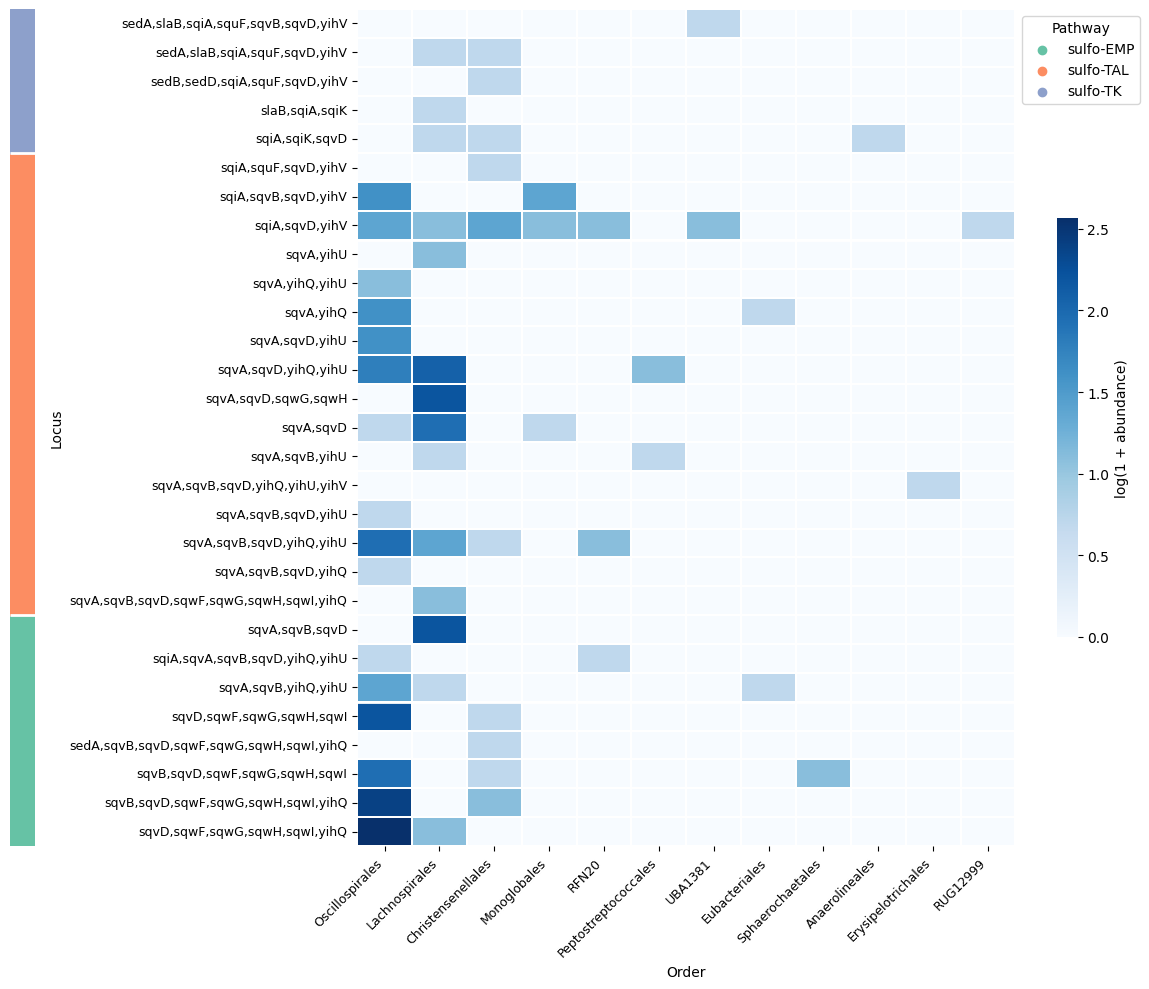

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- locus ---
df_filtered["locus"] = df_filtered["SQ_gene_content_set"].apply(
    lambda x: ",".join(sorted(x.split(",")))
)

# --- order extraction ---
df_filtered["order"] = df_filtered["taxonomy"].apply(
    lambda x: [t for t in x.split(";") if t.startswith("o__")][0].replace("o__", "")
)

# --- pathway per locus ---
locus_pathway = (
    df_filtered
    .groupby("locus")["SQ_pathway"]
    .agg(lambda x: x.mode()[0])
)

# --- raw counts: locus × order ---
heatmap_df = (
    df_filtered
    .groupby(["locus", "order"])
    .size()
    .unstack(fill_value=0)
)

# --- сортировка orders по abundance ---
order_order = heatmap_df.sum(axis=0).sort_values(ascending=False).index
heatmap_df = heatmap_df[order_order]

# --- pathway ---
heatmap_df["pathway"] = heatmap_df.index.map(locus_pathway)
heatmap_df = heatmap_df.sort_values("pathway")

pathway_labels = heatmap_df["pathway"]
heatmap_df = heatmap_df.drop(columns="pathway")

# --- LOG transform ---
heatmap_log = np.log1p(heatmap_df)

# =========================
# 🎨 VISUALIZATION
# =========================

# --- colors ---
pathway_unique = pathway_labels.unique()
palette = sns.color_palette("Set2", len(pathway_unique))
pathway_colors = dict(zip(pathway_unique, palette))
row_colors = pathway_labels.map(pathway_colors)

# --- figure ---
fig, (ax_color, ax) = plt.subplots(
    ncols=2,
    figsize=(12, 10),
    gridspec_kw={"width_ratios": [0.3, 10]}
)

# --- sidebar ---
for i, color in enumerate(row_colors):
    ax_color.add_patch(plt.Rectangle((0, i), 1, 1, color=color))

ax_color.set_xlim(0, 1)
ax_color.set_ylim(0, len(row_colors))
ax_color.axis("off")

# --- heatmap ---
sns.heatmap(
    heatmap_log,
    cmap="Blues",
    ax=ax,
    linewidths=0.2,
    cbar_kws={
        "label": "log(1 + abundance)",
        "shrink": 0.5,
        "aspect": 20
    }
)

# --- pathway boundaries ---
boundaries = []
prev = pathway_labels.iloc[0]

for i, val in enumerate(pathway_labels):
    if val != prev:
        boundaries.append(i)
        prev = val

for b in boundaries:
    ax.hlines(b, *ax.get_xlim(), colors='white', linewidth=2)
    ax_color.hlines(b, *ax_color.get_xlim(), colors='white', linewidth=2)

# --- labels ---
ax.set_xlabel("Order")
ax.set_ylabel("Locus")

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

# --- legend ---
for p, c in pathway_colors.items():
    ax.scatter([], [], color=c, label=p)

ax.legend(
    title="Pathway",
    bbox_to_anchor=(1, 1),
    loc="upper left"
)

plt.tight_layout()

# --- save BEFORE show ---
plt.savefig(
    "../pictures/loci/loci_among_orders_log.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [4]:
def query_gene_set_order(df, gene_set_query=None, order_query=None, show_cols=None):
    """
    Фильтр по SQ_gene_content_set (locus) и order.

    Parameters
    ----------
    df : pd.DataFrame
        исходный датафрейм
    gene_set_query : str or list, optional
        строка или список наборов генов (например "sqiA,sqiK")
    order_query : str or list, optional
        order (например "Oscillospirales")
    show_cols : list, optional
        какие колонки вернуть
    """

    df_q = df.copy()

    # --- order extraction ---
    if "order" not in df_q.columns:
        df_q["order"] = df_q["taxonomy"].apply(
            lambda x: [t for t in x.split(";") if t.startswith("o__")][0].replace("o__", "")
        )

    # --- gene set filter (ВАЖНО: точное совпадение или contains) ---
    if gene_set_query is not None:
        if isinstance(gene_set_query, str):
            df_q = df_q[df_q["SQ_gene_content_set"].str.contains(gene_set_query, na=False)]
        else:
            df_q = df_q[df_q["SQ_gene_content_set"].isin(gene_set_query)]

    # --- order filter ---
    if order_query is not None:
        if isinstance(order_query, str):
            df_q = df_q[df_q["order"].str.contains(order_query, na=False)]
        else:
            df_q = df_q[df_q["order"].isin(order_query)]

    # --- output ---
    if show_cols is not None:
        return df_q[show_cols]

    return df_q

In [7]:
# 2. нормализация наборов генов (сортировка)
df_filtered["locus"] = df_filtered["SQ_gene_content_set"].apply(
    lambda x: ",".join(sorted(x.split(",")))
)

# 3. подсчёт уникальных локусов
unique_loci = df_filtered["locus"].nunique()

print("Количество уникальных локусов:", unique_loci)

# 4. таблица частот
locus_counts = df_filtered["locus"].value_counts()
print(locus_counts)

Количество уникальных локусов: 29
locus
sqiA,sqvD,yihV                             15
sqvD,sqwF,sqwG,sqwH,sqwI,yihQ              14
sqvA,sqvD,yihQ,yihU                        14
sqvB,sqvD,sqwF,sqwG,sqwH,sqwI,yihQ         12
sqvA,sqvB,sqvD,yihQ,yihU                   12
sqvD,sqwF,sqwG,sqwH,sqwI                    9
sqvB,sqvD,sqwF,sqwG,sqwH,sqwI               9
sqvA,sqvD                                   8
sqvA,sqvD,sqwG,sqwH                         8
sqvA,sqvB,sqvD                              8
sqiA,sqvB,sqvD,yihV                         7
sqvA,yihQ                                   5
sqvA,sqvB,yihQ,yihU                         5
sqvA,sqvD,yihU                              4
sqiA,sqiK,sqvD                              3
sedA,slaB,sqiA,squF,sqvD,yihV               2
sqvA,yihQ,yihU                              2
sqiA,sqvA,sqvB,sqvD,yihQ,yihU               2
sqvA,sqvB,yihU                              2
sqvA,sqvB,sqvD,sqwF,sqwG,sqwH,sqwI,yihQ     2
sqvA,yihU                               

In [6]:
query_gene_set_order(
    df_filtered,
    gene_set_query="sqvB,sqvD", #локус
    order_query="Oscillospirales" #порядок
)

,cluster,target,contig,SQ_gene_content_set,SQ_pathway,SQ_score,taxonomy,bitscore_list,evalue_list,order,locus
1,66,"GCA_902754915.1_GLIGFB_00381,GCA_902754915.1_G...",CACVLH010000002.1,"sqvB,sqvD,sqwF,sqwG,sqwH,sqwI",sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[142.0, 217.0, 162.0, 291.0, 298.0, 255.0]","[1.6599999999999999e-40, 5.99e-66, 3.31e-50, 1...",Oscillospirales,"sqvB,sqvD,sqwF,sqwG,sqwH,sqwI"
7,584,"GCA_902755725.1_OGGBFD_01658,GCA_902755725.1_O...",CACVOI010000078.1,"sqvA,sqvB,sqvD,yihQ",sulfo-TAL,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[584.0, 262.0, 152.0, 292.0]","[6.09e-201, 2.5599999999999998e-84, 2.11e-44, ...",Oscillospirales,"sqvA,sqvB,sqvD,yihQ"
20,1440,"GCA_902757025.1_CANEDN_00316,GCA_902757025.1_C...",CACVTL010000002.1,"sqvB,sqvD,sqwF,sqwG,sqwH,sqwI,yihQ",sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[282.0, 291.0, 287.0, 175.0, 203.0, 120.0, 383.0]","[2.13e-89, 1.88e-97, 8.069999999999999e-95, 2....",Oscillospirales,"sqvB,sqvD,sqwF,sqwG,sqwH,sqwI,yihQ"
38,3919,"GCA_902761635.1_AHAPNN_01204,GCA_902761635.1_A...",CACWLG010000014.1,"sqvB,sqvD,sqwF,sqwG,sqwH,sqwI,yihQ",sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[672.0, 257.0, 292.0, 293.0, 164.0, 213.0, 137.0]","[3.1500000000000004e-235, 2.06e-79, 4e-98, 4.4...",Oscillospirales,"sqvB,sqvD,sqwF,sqwG,sqwH,sqwI,yihQ"
132,13660,"GCA_902775995.1_CJGLOE_00969,GCA_902775995.1_C...",CACYOP010000011.1,"sqiA,sqvB,sqvD,yihV",sulfo-EMP,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[97.8, 175.0, 113.0, 132.0]","[1.99e-20, 4.98e-52, 6.37e-28, 7.49e-37]",Oscillospirales,"sqiA,sqvB,sqvD,yihV"
140,14468,"GCA_902777215.1_FFNCOF_00667,GCA_902777215.1_F...",CACYSW010000006.1,"sqiA,sqvA,sqvB,sqvD,yihQ,yihU",sulfo-TAL,max,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[181.0, 586.0, 298.0, 124.0, 168.0, 278.0]","[6.91e-54, 1.63e-201, 6.53e-102, 5.36e-32, 9.9...",Oscillospirales,"sqiA,sqvA,sqvB,sqvD,yihQ,yihU"
150,15163,"GCA_902778275.1_BOKDHH_00817,GCA_902778275.1_B...",CACYXE010000007.1,"sqvB,sqvD,sqwF,sqwG,sqwH,sqwI,yihQ",sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[380.0, 264.0, 290.0, 288.0, 163.0, 213.0, 134.0]","[1.85e-121, 2.18e-82, 2.28e-97, 2.92e-95, 8.13...",Oscillospirales,"sqvB,sqvD,sqwF,sqwG,sqwH,sqwI,yihQ"
158,16545,"GCA_902779945.1_HKIONG_00608,GCA_902779945.1_H...",CACZDN010000005.1,"sqvB,sqvD,sqwF,sqwG,sqwH,sqwI,yihQ",sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[124.0, 194.0, 153.0, 290.0, 293.0, 278.0, 667.0]","[1.66e-33, 4.87e-57, 2.11e-46, 5.11e-96, 2.72e...",Oscillospirales,"sqvB,sqvD,sqwF,sqwG,sqwH,sqwI,yihQ"
197,19092,"GCA_902782845.1_COMMNG_01676,GCA_902782845.1_C...",CACZOP010000208.1,"sqvA,sqvB,sqvD,yihQ,yihU",sulfo-TAL,max,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[574.0, 280.0, 123.0, 161.0, 251.0]","[7.079999999999999e-197, 9.369999999999999e-95...",Oscillospirales,"sqvA,sqvB,sqvD,yihQ,yihU"
216,20498,"GCA_902783755.1_GIHBOO_00780,GCA_902783755.1_G...",CACZSC010000128.1,"sqvB,sqvD,sqwF,sqwG,sqwH,sqwI",sulfo-TK,min_up,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,"[130.0, 211.0, 156.0, 281.0, 280.0, 267.0]","[8.28e-36, 1.02e-63, 6.219999999999999e-48, 1....",Oscillospirales,"sqvB,sqvD,sqwF,sqwG,sqwH,sqwI"
